PARTE 1
----


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("datos_empresas_examen.csv")



Los primeros 5 registros

In [2]:
df.head(5)

,id,empresa,sector,año,ingresos_mill_eur,costes_mill_eur,beneficio_mill_eur,empleados,region
0,1,RetailPlus,Retail,2020,139.87,111.25,28.62,301.0,Europa
1,2,SoftSystems,Tecnología,2022,180.92,153.26,27.66,NaN,América
2,3,SoftSystems,Tecnología,2015,183.17,145.50,37.67,212.0,Asia
3,4,TechNova,Tecnología,2020,141.70,116.33,25.37,212.0,América
4,5,InduWare,Industrial,2022,129.68,118.81,10.87,112.0,América


El numero de filas y columnas

In [3]:
print(f"El numero de filas es de {df.shape[0]} y de columnas {df.shape[1]}")

El numero de filas es de 510 y de columnas 9


El tipo de datos por columna

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  510 non-null    int64  
 1   empresa             510 non-null    object 
 2   sector              510 non-null    object 
 3   año                 510 non-null    int64  
 4   ingresos_mill_eur   469 non-null    float64
 5   costes_mill_eur     468 non-null    float64
 6   beneficio_mill_eur  510 non-null    float64
 7   empleados           469 non-null    float64
 8   region              469 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 36.0+ KB


Estadística descriptiva de las columnas númericas 

In [7]:
df.select_dtypes(include=['number']).describe()


,id,año,ingresos_mill_eur,costes_mill_eur,beneficio_mill_eur,empleados
count,510.000000,510.000000,469.000000,468.000000,510.000000,469.000000
mean,250.235294,2019.300000,128.328380,94.096603,29.636902,261.294243
std,144.217608,2.774817,59.910187,38.040591,9.943392,112.276382
min,1.000000,2015.000000,4.150000,0.000000,-2.410000,22.000000
25%,125.250000,2017.000000,97.500000,67.880000,22.575000,198.000000
50%,250.500000,2019.000000,124.810000,92.480000,29.700000,256.000000
75%,374.750000,2022.000000,146.520000,119.222500,36.672500,306.000000
max,500.000000,2024.000000,665.360000,201.230000,60.790000,1278.000000


Número total de valores nulos por columna

In [8]:
df.isnull().sum()

id                     0
empresa                0
sector                 0
año                    0
ingresos_mill_eur     41
costes_mill_eur       42
beneficio_mill_eur     0
empleados             41
region                41
dtype: int64

Podemos observar que tenemos 4 columnas de nuestro df que si tienen valores nulos, que son 41 mas o menos los valores nulos que hay

Número de registros duplicados 

In [37]:
df.duplicated().sum()

0

---------

 ## PARTE 2

En las columnas numéricas(ingresos_mil_eur, costes_mil_eur, empleados), imputa los valores nulos usando la media, excepto empleados con la mediana

In [18]:
media_ingresos = df['ingresos_mill_eur'].mean()
media_costes = df['costes_mill_eur'].mean()
mediana_empleados = df['empleados'].median()
df['ingresos_mill_eur'].fillna(media_ingresos, inplace=True)
df['costes_mill_eur'].fillna(media_costes, inplace=True)
df['empleados'].fillna(mediana_empleados, inplace=True)# le ponemos los inplace para que actualice el df

Para comprobarlo volvemos a lanzar la funcion isnull()

In [19]:
df.isnull().sum()

id                     0
empresa                0
sector                 0
año                    0
ingresos_mill_eur      0
costes_mill_eur        0
beneficio_mill_eur     0
empleados              0
region                41
dtype: int64

En la columna región, imputa los valores mas frecuentes con la moda o el valor más frecuente, en su defecto por desconido (puntua menos con desconocido)

In [23]:
df['region'].fillna(df['region'].mode()[0], inplace= True) # es un dato categorico (no numerico)
df['region']

0       Europa
1      América
2         Asia
3      América
4      América
        ...   
505       Asia
506    América
507    América
508    América
509     Europa
Name: region, Length: 510, dtype: object

Muestra cuántos valores nulos quedan después del tratamiento , Volvemos a revisar

In [24]:
df.isnull().sum()

id                    0
empresa               0
sector                0
año                   0
ingresos_mill_eur     0
costes_mill_eur       0
beneficio_mill_eur    0
empleados             0
region                0
dtype: int64

Elimación de duplicados, elimina los registros duplicados manteniendo el primero

In [28]:
df.drop_duplicates(keep='first', inplace=True)

Muestra cuántos registros han sidos eliminados

In [29]:
# Como habían anteriorme 510 como bien vemos arriba al hacer el shape , simplemente restamos a los actuales ya si podemos ver cuantos registros fueron eliminados
print(f"Número de registros eliminados {510- df.shape[0]}")

Número de registros eliminados 10


------------------

## PARTE 3

Crea una nueva columna llamada margen_beneficio

In [30]:
df['margen_beneficio'] = df['beneficio_mill_eur']/df['ingresos_mill_eur']


Mostramos para ver la columna nueva

In [33]:
df['margen_beneficio'].head()

0    0.204619
1    0.152885
2    0.205656
3    0.179040
4    0.083822
Name: margen_beneficio, dtype: float64

Crea col cagtegoria_empresa segun ingresos: 

In [34]:
df['categoria_empresa'] = df['ingresos_mill_eur'].apply(lambda x: 'Baja' if x <80 else('Media' if x <140 else 'Alta' ))
df['categoria_empresa'].head() #mostramos para verificar el cambio


0    Media
1     Alta
2     Alta
3     Alta
4    Media
Name: categoria_empresa, dtype: object

Calcula y muestra: beneficio medio por sector, ingresos totales por año, empleados medios por región

In [44]:
beneficio_medio = df.groupby('sector')['beneficio_mill_eur'].mean()
ingresos_total_ano= df.groupby('año')['ingresos_mill_eur'].sum().mean()
empleados_medios_region = df.groupby('region')['empleados'].mean()
print(f'''El beneficio medio por sector es: {beneficio_medio}
Los ingresos totales por año son de : {ingresos_total_ano} 
Los empleados medios por región son de: {empleados_medios_region}
''')

El beneficio medio por sector es: sector
Energía       30.278936
Industrial    29.712667
Retail        30.129355
Servicios     27.804375
Tecnología    29.497862
Name: beneficio_mill_eur, dtype: float64
Los ingresos totales por año son de : 6432.584518123667 
Los empleados medios por región son de: region
América    262.058252
Asia       260.328467
Europa     260.299363
Name: empleados, dtype: float64



------------

## PARTE 4

Gráfico de líneas : evolución de ingresos por año agrupando por empresa(promedio anual)

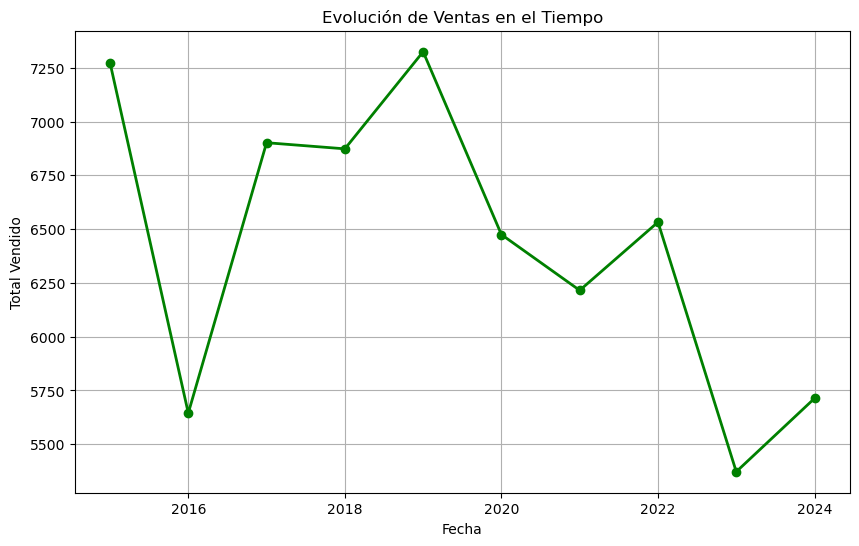

In [43]:
# --- LÍNEAS --
plt.figure(figsize=(10, 6))

datos = df.groupby('año')['ingresos_mill_eur'].sum()
datos.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Evolución de Ventas en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Total Vendido')
plt.grid(True)
plt.show()


Boxplot, comparación del beneficio entre sectores

<Figure size 1000x600 with 0 Axes>

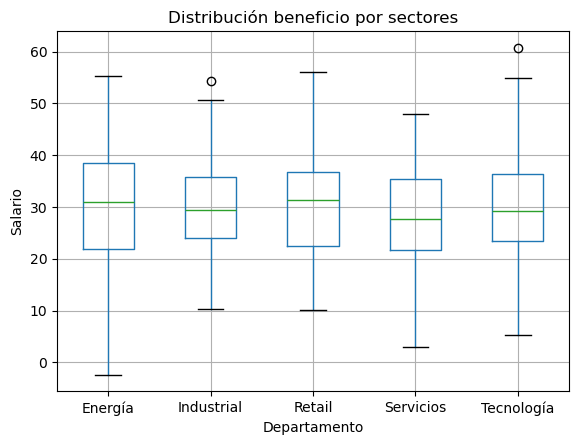

In [45]:
# --- BOXPLOT --
plt.figure(figsize=(10, 6))
df.boxplot(column='beneficio_mill_eur', by='sector')
plt.title('Distribución beneficio por sectores')
plt.suptitle('') # Borra el subtítulo automático feo de Pandas
plt.xlabel('Departamento')
plt.ylabel('Salario')
plt.show()

Gráfico de dispersión, relación entre empleados e ingresos, coloreado por sector

<Figure size 1000x600 with 0 Axes>

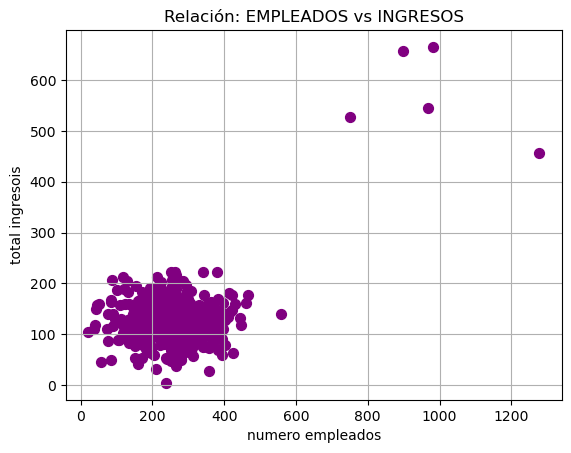

In [55]:
# --- DISPERSIÓN --
plt.figure(figsize=(10, 6))
df.plot(kind='scatter', x='empleados', y='ingresos_mill_eur', color='purple', s=50)
# s=50 es el tamaño de los puntos
plt.title('Relación: EMPLEADOS vs INGRESOS')
plt.xlabel('numero empleados')
plt.ylabel('total ingresois')
plt.grid(True)
plt.show()


Gráfico de barras, ingresos totales por región

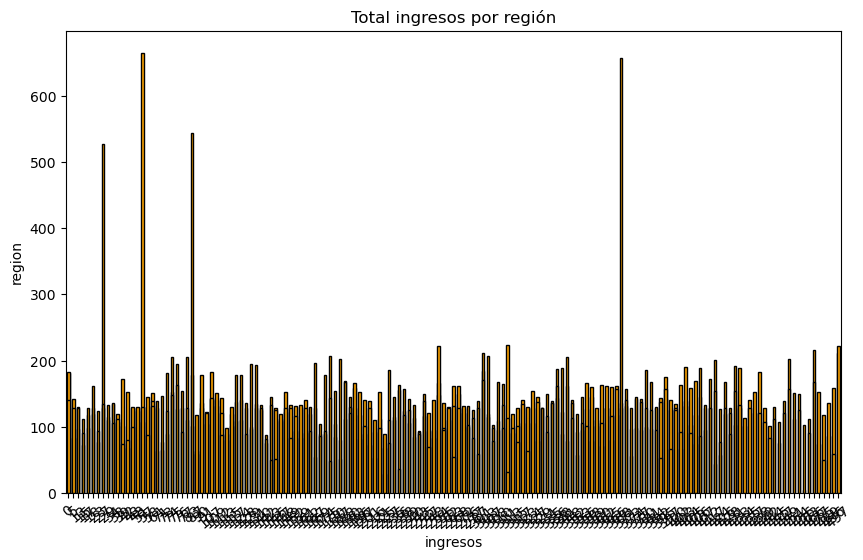

In [54]:
# --- BARRAS --
plt.figure(figsize=(10, 6))
conteo = df.groupby(by='region')['ingresos_mill_eur']
# Para pintar:
conteo.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Total ingresos por región')
plt.xlabel('ingresos')
plt.ylabel('region')
plt.xticks(rotation=40)
plt.show()

-------

## PARTE 5 

5.1 -> Servivios, que habrá que prestar atención a ese sector

5.2 -> A medida que aumenta la variable x que son nuestros empleados tiende a disminiur la concentración pero antes podemos ver que al concentración es fuerte dado que los grupos de puntos estan muy concentrados

5.3 -> 
